<a href="https://colab.research.google.com/github/2326-aar/Task-3/blob/main/House_price_task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First few rows of the data:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Model Evaluation:
MAE: 722691.556683017
MSE: 937926527372.9823
R² Scor

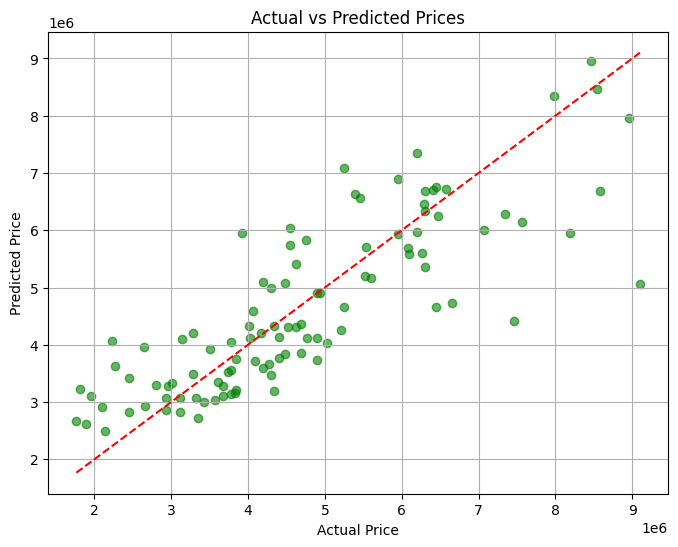

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Step 1: Load the dataset
data = pd.read_csv('/content/data task 3.csv')
print("First few rows of the data:")
print(data.head())

# Step 2: Handle categorical variables using one-hot encoding
categorical_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                       'airconditioning', 'prefarea', 'furnishingstatus']
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

# Step 3: Remove outliers from 'price' and 'area'
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[column] >= Q1 - 1.5 * IQR) & (df[column] <= Q3 + 1.5 * IQR)]

data = remove_outliers(data, 'price')
data = remove_outliers(data, 'area')

# Step 4: Log transform skewed features
data['log_price'] = np.log(data['price'])
data['log_area'] = np.log(data['area'])

# Step 5: Prepare features (X) and target (y)
X = data.drop(['price', 'area', 'log_price'], axis=1)
y = data['log_price']

# Step 6: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 8: Train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Step 9: Make predictions
y_pred_log = model.predict(X_test_scaled)
y_pred = np.exp(y_pred_log)           # Convert back to original price scale
y_test_actual = np.exp(y_test)

# Step 10: Evaluate the model
print("\nModel Evaluation:")
print("MAE:", mean_absolute_error(y_test_actual, y_pred))
print("MSE:", mean_squared_error(y_test_actual, y_pred))
print("R² Score:", r2_score(y_test_actual, y_pred))

# Step 11: Visualize Actual vs Predicted Prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_pred, alpha=0.6, color='green')
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         color='red', linestyle='--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.grid(True)
plt.show()
